<a href="https://colab.research.google.com/github/asheta66/Applications/blob/main/ViT_from_scratch_Alzheimer's%20Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Improved Vision Transformer (ViT) from Scratch for Chest X-Ray Classification

This notebook trains a **Vision Transformer from scratch** to classify chest X-rays as **NORMAL** or **PNEUMONIA**.

### Main improvements over the original notebook
- Uses the **full available dataset** instead of limiting each class to 100 images.
- Uses medically more reasonable augmentation (small rotation, translation, zoom, brightness changes; no vertical flips or 90°/180° rotations).
- Uses **16×16 patches** instead of 7×7 patches, reducing the token sequence from 1024 to 196 patches for 224×224 images.
- Uses a smaller, more data-appropriate ViT with **4 Transformer blocks**.
- Uses the correct per-head attention dimension.
- Replaces `Flatten()` with `GlobalAveragePooling1D()` to greatly reduce classifier parameters and overfitting.
- Uses **AdamW** with weight decay and cosine learning-rate decay.
- Uses class weights to address class imbalance without discarding images.
- Tracks accuracy, ROC-AUC, precision, and recall.
- Selects the best model using **validation AUC**.
- Evaluates only once on the held-out test set after training.
- Produces a confusion matrix, classification report, sensitivity, specificity, ROC curve, and training curves.

> **Important:** This is still a ViT trained from scratch. A pretrained ViT/CNN will generally perform better on a dataset of this size, but this notebook keeps the from-scratch requirement.


## 1. Libraries and Reproducibility

In [ ]:

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras.layers as L

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Google Drive and Build the Full Dataset

In [ ]:

from google.colab import drive

MOUNT_POINT = "/content/mydrive"
drive.mount(MOUNT_POINT)

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------
IMAGE_SIZE = 224
BATCH_SIZE = 16
N_CLASSES = 2
RANDOM_STATE = 42

# Change only this path if your Drive folder is different.
DRIVE_DATA_DIR = Path(f"{MOUNT_POINT}/MyDrive/Chest X_Ray")

NORMAL_DIR = DRIVE_DATA_DIR / "NORMAL"
PNEUMONIA_DIR = DRIVE_DATA_DIR / "PNEUMONIA"

OUTPUT_DIR = Path(f"{MOUNT_POINT}/MyDrive/Chest_XRay_ViT_Results_Improved")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

SUPPORTED_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
}

def find_image_files(folder):
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ])

if not DRIVE_DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DRIVE_DATA_DIR}")
if not NORMAL_DIR.exists():
    raise FileNotFoundError(f"NORMAL folder not found: {NORMAL_DIR}")
if not PNEUMONIA_DIR.exists():
    raise FileNotFoundError(f"PNEUMONIA folder not found: {PNEUMONIA_DIR}")

normal_files = find_image_files(NORMAL_DIR)
pneumonia_files = find_image_files(PNEUMONIA_DIR)

if len(normal_files) == 0 or len(pneumonia_files) == 0:
    raise ValueError("One or both class folders contain no supported images.")

data = (
    [{"image_path": str(p), "label": 0, "class_name": "NORMAL"} for p in normal_files]
    + [{"image_path": str(p), "label": 1, "class_name": "PNEUMONIA"} for p in pneumonia_files]
)

df = pd.DataFrame(data).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("=" * 70)
print("FULL CHEST X-RAY DATASET")
print("=" * 70)
print(f"NORMAL images    : {len(normal_files):,}")
print(f"PNEUMONIA images : {len(pneumonia_files):,}")
print(f"Total images     : {len(df):,}")
print("\nClass distribution:")
print(df["class_name"].value_counts())


Mounted at /content/mydrive
FULL CHEST X-RAY DATASET
NORMAL images    : 1,583
PNEUMONIA images : 4,273
Total images     : 5,856

Class distribution:
class_name
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


## 3. Stratified Train / Validation / Test Split

In [ ]:

# 70% train, 15% validation, 15% test
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

df_valid, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["label"],
    random_state=RANDOM_STATE,
)

df_train = df_train.reset_index(drop=True)
df_valid = df_valid.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)
print(f"Training images   : {len(df_train):,}")
print(f"Validation images : {len(df_valid):,}")
print(f"Testing images    : {len(df_test):,}")

for name, split_df in [
    ("Train", df_train),
    ("Validation", df_valid),
    ("Test", df_test),
]:
    print(f"\n{name}:")
    print(split_df["class_name"].value_counts())


DATASET SPLIT
Training images   : 4,099
Validation images : 878
Testing images    : 879

Train:
class_name
PNEUMONIA    2991
NORMAL       1108
Name: count, dtype: int64

Validation:
class_name
PNEUMONIA    641
NORMAL       237
Name: count, dtype: int64

Test:
class_name
PNEUMONIA    641
NORMAL       238
Name: count, dtype: int64


## 4. Data Generators and Medically Conservative Augmentation

In [ ]:

# No vertical flips and no 90/180/270-degree rotations.
# These transformations would create unrealistic chest radiographs.

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    brightness_range=(0.90, 1.10),
    fill_mode="nearest",
)

eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col="image_path",
    y_col="class_name",
    classes=CLASS_NAMES,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=RANDOM_STATE,
)

valid_gen = eval_datagen.flow_from_dataframe(
    dataframe=df_valid,
    x_col="image_path",
    y_col="class_name",
    classes=CLASS_NAMES,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

test_gen = eval_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="image_path",
    y_col="class_name",
    classes=CLASS_NAMES,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)


Found 4099 validated image filenames belonging to 2 classes.
Found 878 validated image filenames belonging to 2 classes.
Found 879 validated image filenames belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 5. Compute Class Weights

In [ ]:

# Preserve all images and compensate for imbalance with class weights.
class_ids = np.array(sorted(df_train["label"].unique()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=df_train["label"].values,
)

class_weight = {int(cls): float(w) for cls, w in zip(class_ids, weights)}

print("Class weights:", class_weight)


Class weights: {0: 1.8497292418772564, 1: 0.6852223336676697}


## 6. Visualize Sample Training Images

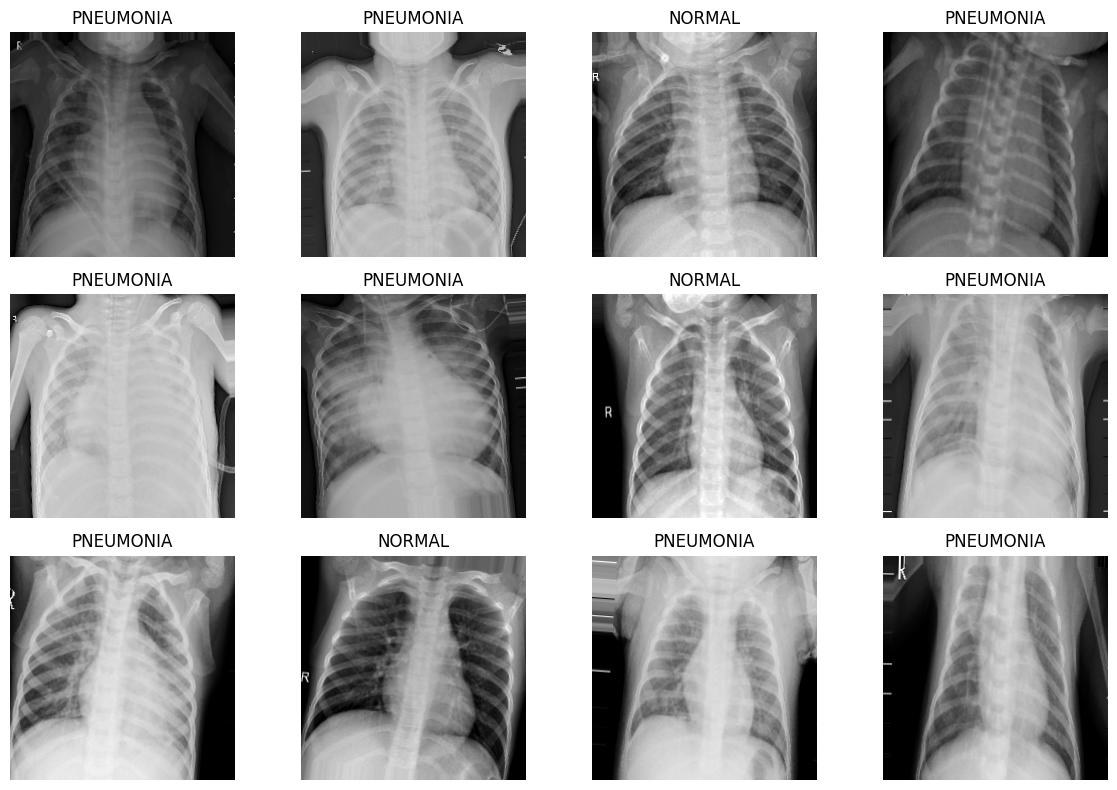

In [ ]:

images, labels = next(train_gen)

plt.figure(figsize=(12, 8))

n_show = min(12, len(images))
for i in range(n_show):
    ax = plt.subplot(3, 4, i + 1)
    ax.imshow(np.clip(images[i], 0, 1))
    ax.set_title(CLASS_NAMES[int(labels[i])])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Reset so visualization does not affect the starting position of training.
train_gen.reset()


## 7. ViT Hyperparameters

In [ ]:

PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4

TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]

MLP_HEAD_UNITS = [128, 64]

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 40

print(f"Image size          : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Patch size          : {PATCH_SIZE} x {PATCH_SIZE}")
print(f"Number of patches   : {NUM_PATCHES}")
print(f"Projection dimension: {PROJECTION_DIM}")
print(f"Attention heads     : {NUM_HEADS}")
print(f"Transformer blocks  : {TRANSFORMER_LAYERS}")


Image size          : 224 x 224
Patch size          : 16 x 16
Number of patches   : 196
Projection dimension: 64
Attention heads     : 4
Transformer blocks  : 4


## 8. MLP, Patch Extraction, and Positional Encoding

In [ ]:

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = L.Dense(units, activation=tf.nn.gelu)(x)
        x = L.Dropout(dropout_rate)(x)
    return x


class Patches(L.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEncoder(L.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = L.Dense(projection_dim)
        self.position_embedding = L.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim,
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config


## 9. Visualize the 16×16 Patch Grid

Patch tensor shape: (1, 196, 768)
Patches per image: 196


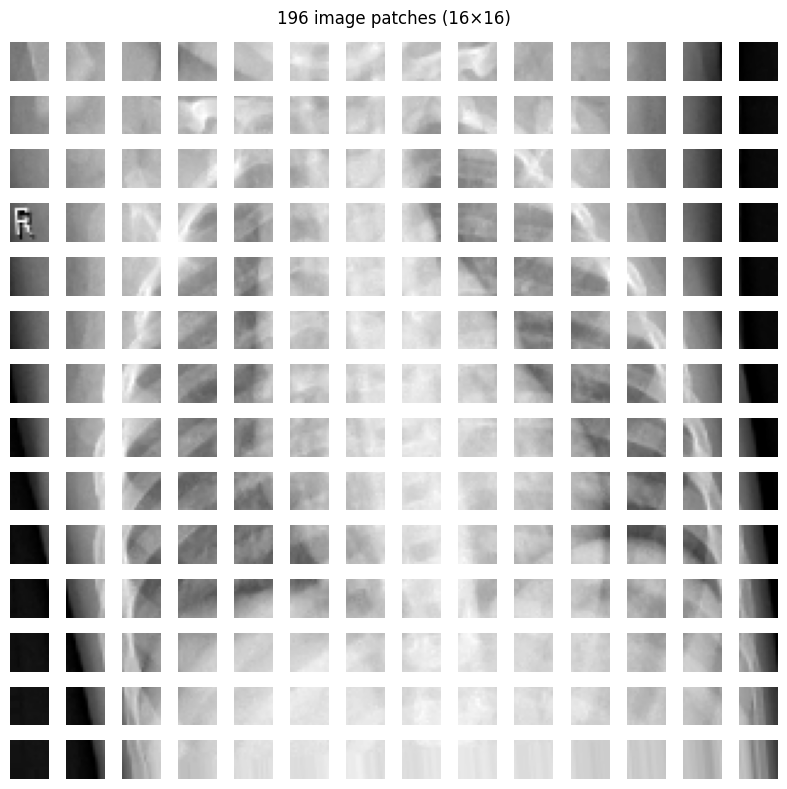

In [ ]:

sample_images, _ = next(train_gen)
sample_image = sample_images[0]

patch_tensor = Patches(PATCH_SIZE)(
    tf.expand_dims(sample_image, axis=0)
)

print("Patch tensor shape:", patch_tensor.shape)
print("Patches per image:", patch_tensor.shape[1])

grid_size = IMAGE_SIZE // PATCH_SIZE

plt.figure(figsize=(8, 8))
for i, patch in enumerate(patch_tensor[0]):
    ax = plt.subplot(grid_size, grid_size, i + 1)
    patch_img = tf.reshape(patch, (PATCH_SIZE, PATCH_SIZE, 3))
    ax.imshow(np.clip(patch_img.numpy(), 0, 1))
    ax.axis("off")

plt.suptitle(f"{NUM_PATCHES} image patches ({PATCH_SIZE}×{PATCH_SIZE})")
plt.tight_layout()
plt.show()

train_gen.reset()


## 10. Build the Improved Vision Transformer

In [ ]:

def build_vit_classifier():
    inputs = L.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

    # Patch extraction and encoding
    patches = Patches(PATCH_SIZE, name="patches")(inputs)
    encoded_patches = PatchEncoder(
        NUM_PATCHES,
        PROJECTION_DIM,
        name="patch_encoder",
    )(patches)

    # Transformer encoder blocks
    for block_idx in range(TRANSFORMER_LAYERS):
        x1 = L.LayerNormalization(
            epsilon=1e-6,
            name=f"block_{block_idx + 1}_ln1",
        )(encoded_patches)

        attention_output = L.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=0.1,
            name=f"block_{block_idx + 1}_attention",
        )(x1, x1)

        x2 = L.Add(
            name=f"block_{block_idx + 1}_skip1"
        )([encoded_patches, attention_output])

        x3 = L.LayerNormalization(
            epsilon=1e-6,
            name=f"block_{block_idx + 1}_ln2",
        )(x2)

        x3 = mlp(
            x3,
            hidden_units=TRANSFORMER_UNITS,
            dropout_rate=0.1,
        )

        encoded_patches = L.Add(
            name=f"block_{block_idx + 1}_skip2"
        )([x2, x3])

    # Compact image representation instead of Flatten().
    representation = L.LayerNormalization(
        epsilon=1e-6,
        name="final_layer_norm",
    )(encoded_patches)

    representation = L.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(representation)

    representation = L.Dropout(0.30)(representation)

    features = mlp(
        representation,
        hidden_units=MLP_HEAD_UNITS,
        dropout_rate=0.30,
    )

    outputs = L.Dense(
        1,
        activation="sigmoid",
        name="pneumonia_probability",
    )(features)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ViT_Chest_XRay_From_Scratch",
    )


model = build_vit_classifier()
model.summary()


Model: "ViT_Chest_XRay_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ln1         │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attention   │ (None, 196, 64)   │     16,640 │ block_1_ln1[0][0… │
│ (MultiHeadAttentio… │                   │            │ block_1_ln1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_skip1 (Add) │ (None, 196, 64)   │          0 │ patch_encoder[0]… │
│                     │                   │            │ block_1_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ln2         │ (None, 196, 64)   │        128 │ block_1_skip1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ block_1_ln2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_skip2 (Add) │ (None, 196, 64)   │          0 │ block_1_skip1[0]… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ln1         │ (None, 196, 64)   │        128 │ block_1_skip2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attention   │ (None, 196, 64)   │     16,640 │ block_2_ln1[0][0… │
│ (MultiHeadAttentio… │                   │            │ block_2_ln1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_skip1 (Add) │ (None, 196, 64)   │          0 │ block_1_skip2[0]… │
│                     │                   │            │ block_2_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ln2         │ (None, 196, 64)   │        128 │ block_2_skip1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ block_2_ln2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 196, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 212,417 (829.75 KB)

 Trainable params: 212,417 (829.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

def print_class_distribution(generator, name):
    labels, counts = np.unique(generator.classes, return_counts=True)

    print(f"\n{name}:")
    for label, count in zip(labels, counts):
        class_name = CLASS_NAMES[label]
        print(f"  {class_name}: {count}")
    print(f"  Total: {generator.n}")

print_class_distribution(train_gen, "Training Set")
print_class_distribution(valid_gen, "Validation Set")
print_class_distribution(test_gen, "Test Set")

## 11. AdamW + Cosine Learning-Rate Schedule

In [ ]:

steps_per_epoch = int(np.ceil(train_gen.n / train_gen.batch_size))
decay_steps = steps_per_epoch * EPOCHS

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=decay_steps,
    alpha=0.05,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

print("Steps per epoch:", steps_per_epoch)
print("Total decay steps:", decay_steps)


Steps per epoch: 257
Total decay steps: 10280


## 12. Train the Model

In [ ]:

best_model_path = OUTPUT_DIR / "best_vit_chest_xray.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(OUTPUT_DIR / "training_history.csv")
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5310 - auc: 0.5506 - loss: 0.7046 - precision: 0.7556 - recall: 0.5295
Epoch 1: val_auc improved from None to 0.74154, saving model to /content/mydrive/MyDrive/Chest_XRay_ViT_Results_Improved/best_vit_chest_xray.keras

Epoch 1: finished saving model to /content/mydrive/MyDrive/Chest_XRay_ViT_Results_Improved/best_vit_chest_xray.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 1355s 5s/step - accuracy: 0.5718 - auc: 0.6290 - loss: 0.6728 - precision: 0.7948 - recall: 0.5570 - val_accuracy: 0.6276 - val_auc: 0.7415 - val_loss: 0.6107 - val_precision: 0.8504 - val_recall: 0.5944
Epoch 2/40
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6719 - auc: 0.7417 - loss: 0.6132 - precision: 0.8894 - recall: 0.6287
Epoch 2: val_auc improved from 0.74154 to 0.78035, saving model to /content/mydrive/MyDrive/Chest_XRay_ViT_Results_Improved/best_vit_chest_xray.keras

Epoch 2: finished saving model to /content/mydrive/MyDrive/Chest_XRay_ViT_Re

## 13. Plot Training Curves

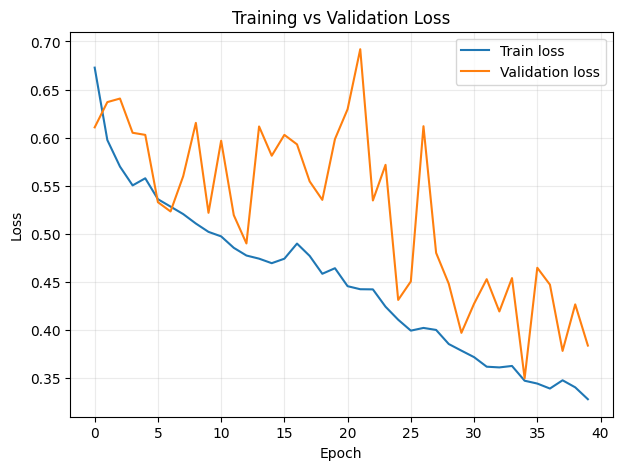

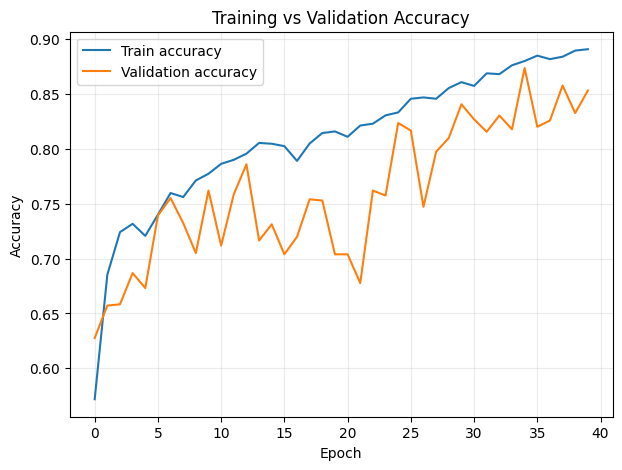

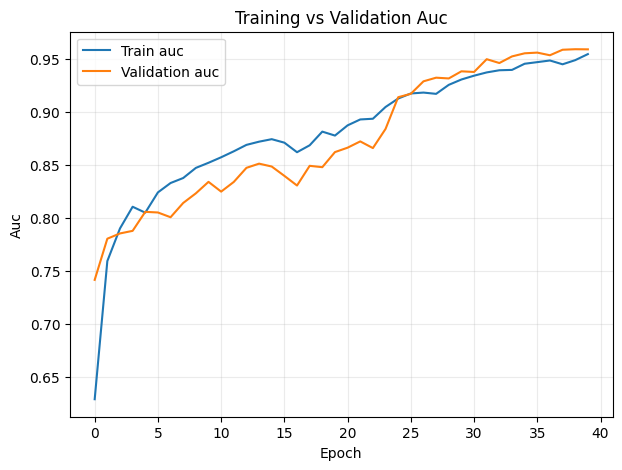

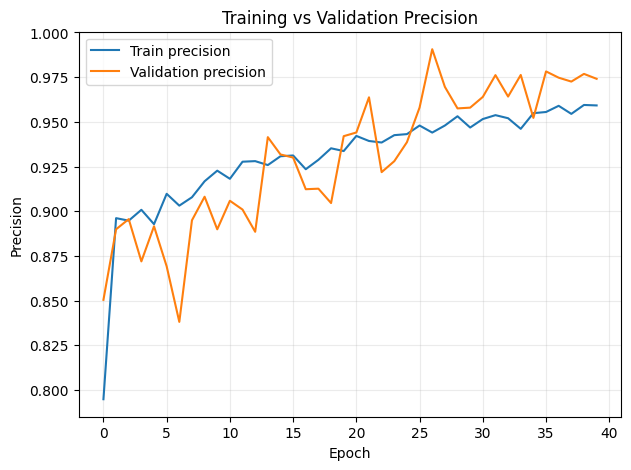

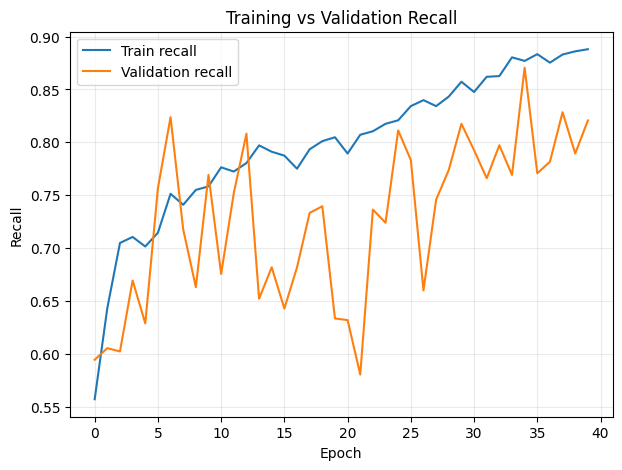

In [ ]:

history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / "history_dataframe.csv", index=False)

for metric in ["loss", "accuracy", "auc", "precision", "recall"]:
    if metric not in history.history:
        continue

    plt.figure(figsize=(7, 5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.title())
    plt.title(f"Training vs Validation {metric.title()}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()



## 14. Final Held-Out Test Evaluation

The test set has not been used for model selection. The following cells evaluate the final model on the held-out test split.


In [ ]:

test_gen.reset()

test_results = model.evaluate(
    test_gen,
    verbose=1,
    return_dict=True,
)

print("\nFINAL TEST METRICS")
print("=" * 50)
for name, value in test_results.items():
    print(f"{name:12s}: {value:.4f}")


29/55 ━━━━━━━━━━━━━━━━━━━━ 1:53 4s/step - accuracy: 0.8757 - auc: 0.9673 - loss: 0.3536 - precision: 0.9672 - recall: 0.8585

## 15. Confusion Matrix, Sensitivity, Specificity, and Classification Report

In [ ]:

test_gen.reset()

y_prob = model.predict(test_gen, verbose=1).ravel()
y_true = test_gen.classes.astype(int)

# Default operating threshold.
THRESHOLD = 0.50
y_pred = (y_prob >= THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0
test_auc = roc_auc_score(y_true, y_prob)

print("Confusion Matrix:")
print(cm)

print(f"\nSensitivity / Recall for PNEUMONIA: {sensitivity:.4f}")
print(f"Specificity for NORMAL            : {specificity:.4f}")
print(f"ROC-AUC                           : {test_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], CLASS_NAMES)
plt.yticks([0, 1], CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.tight_layout()
plt.show()


## 16. ROC Curve

In [ ]:

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ViT ROC-AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Held-Out Test Set")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 17. Save Test Predictions and Metrics

In [ ]:

predictions_df = df_test.copy()
predictions_df["true_label"] = y_true
predictions_df["pneumonia_probability"] = y_prob
predictions_df["predicted_label"] = y_pred
predictions_df["predicted_class"] = [
    CLASS_NAMES[x] for x in y_pred
]

predictions_path = OUTPUT_DIR / "test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

metrics_df = pd.DataFrame([{
    **test_results,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "roc_auc_sklearn": test_auc,
    "threshold": THRESHOLD,
}])

metrics_path = OUTPUT_DIR / "test_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", metrics_path)
print("Best model:", best_model_path)



# Summary and Next Experiments

This version is designed as a stronger **from-scratch ViT baseline**.

For additional experiments, change **one variable at a time** and compare validation AUC:

1. `PATCH_SIZE`: compare 16 vs 32.
2. `TRANSFORMER_LAYERS`: compare 4 vs 6.
3. `PROJECTION_DIM`: compare 64 vs 96.
4. `LEARNING_RATE`: compare `3e-4` vs `1e-4`.
5. `BATCH_SIZE`: compare 16 vs 32 if GPU memory allows.
6. Try grayscale images only if you also change the model input to one channel.
7. For the highest likely performance, compare this from-scratch model against a **pretrained** ViT, DenseNet, EfficientNet, or ConvNeXt model.

### Interpretation note
Accuracy alone is not enough for pneumonia classification. Pay close attention to:
- **Sensitivity/recall**: how many pneumonia cases are detected.
- **Specificity**: how many normal cases are correctly identified.
- **ROC-AUC**: threshold-independent discrimination.
- The confusion matrix and the effect of changing the classification threshold.

This notebook is intended for research/educational evaluation, not clinical deployment.
